Alunos: Ana Carolina, Jairson, Gustavo

**Passo 1: Escolha de Caso**

Tema: Banco para realizar a análise preditiva do preço de fechamento do Bitcoin.

Fonte de dados: Yahoo Finance via biblioteca yfinance.

Variáveis dependentes do tempo: Preço de Abertura, Máxima, Mínima, Fechamento e Volume (OHLCV) coletados diariamente.



**Passo 2: Coleta de Dados**

In [ ]:
import yfinance as yf
import pandas as pd
import sqlite3

ticker = "BTC-USD"
df_raw = yf.download(ticker, start="2021-01-01", end="2026-03-19")

# se o yfinance trouxer colunas extras (MultiIndex), aqui simplifica
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

/tmp/ipykernel_17207/3145954173.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(ticker, start="2021-01-01", end="2026-03-19")
[*********************100%***********************]  1 of 1 completed


**Passo 3: Armazenamento de Dados**

In [ ]:
conn = sqlite3.connect('crypto_data.db')

# index_label='Date' para data também virar uma coluna consultável
df_raw.to_sql('bitcoin_history', conn, if_exists='replace', index=True, index_label='Date')

query = "SELECT * FROM bitcoin_history WHERE Close > 50000 LIMIT 5" # pega os dias em que o preço de fechamento acabou sendo maior que 50000
df_sql = pd.read_sql(query, conn)

print(df_sql.head())

conn.close()

                  Date         Close          High           Low  \
0  2021-02-17 00:00:00  52149.007812  52533.914062  49072.378906   
1  2021-02-18 00:00:00  51679.796875  52474.105469  51015.765625   
2  2021-02-19 00:00:00  55888.132812  56113.652344  50937.277344   
3  2021-02-20 00:00:00  56099.519531  57505.226562  54626.558594   
4  2021-02-21 00:00:00  57539.945312  58330.570312  55672.609375   

           Open       Volume  
0  49207.277344  80820545404  
1  52140.972656  52054723579  
2  51675.980469  63495496918  
3  55887.335938  68145460026  
4  56068.566406  51897585191  


**Passo 4: Tratamento e Limpeza de Dados**

Aqui removemos valores nulos e aplicamos a normalização.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# criando as médias antes de limpar
df_clean = df_raw.copy()
df_clean['SMA_7'] = df_clean['Close'].rolling(window=7).mean() # curto prazo: pega a média dos últimos 7 dias (entender a tendência imediata)
df_clean['SMA_30'] = df_clean['Close'].rolling(window=30).mean() # longo prazo: pega a média dos últimos 30 dias (identificar o "sentimento" do mercado no último mês)

# remove as linhas com NaN (6 dias anteriores, que não tem histórico pra calcular)
df_clean = df_clean.dropna()

scaler = MinMaxScaler()
cols_to_scale = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_7', 'SMA_30']

df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale]) # escala pros valores originais (agora ficarao entre 0 e 1 - sendo 1 o valor máximo)

print(f"novo tamanho do dataset: {df_clean.shape[0]} linhas.")
df_clean.head()

novo tamanho do dataset: 1874 linhas.


Price,Close,High,Low,Open,Volume,SMA_7,SMA_30
Date,,,,,,,
2021-01-30,0.169616,0.169009,0.161168,0.169897,0.173045,0.154685,0.179740
2021-01-31,0.159015,0.164039,0.154940,0.169667,0.137206,0.155792,0.180977
2021-02-01,0.162895,0.167221,0.156000,0.159056,0.162220,0.157364,0.181443
2021-02-02,0.181003,0.178670,0.166270,0.162897,0.167104,0.161310,0.182345
2021-02-03,0.199007,0.193070,0.184438,0.181046,0.161544,0.170759,0.184164


**Passo 5: Preparação para o Aprendizado de Máquina**

"X" (entrada) como o preço de hoje e o "y" (saída/target) o preço de amanhã.

In [ ]:
# variável 'Target' com o preço do dia seguinte
df_clean['Target'] = df_clean['Close'].shift(-1)

# removendo a última linha que não terá um target para o futuro imediato
df_final = df_clean.dropna()

print("funcionou")
print(f"colunas: {df_final.columns.tolist()}")

df_final.to_csv("dados_bitcoin_preparados.csv")

from google.colab import files
files.download("dados_bitcoin_preparados.csv")

funcionou
colunas: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'SMA_30', 'Target']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import sqlite3

from google.colab import files
uploaded = files.upload()

nome_arquivo_csv = 'dados_bitcoin_preparados.csv'
df = pd.read_csv(nome_arquivo_csv)

conn = sqlite3.connect('bitcoin_data.db')

df.to_sql('bitcoin_prices', conn, if_exists='replace', index=False)

conn.close()

print("Banco de dados criado")

Saving dados_bitcoin_preparados.csv to dados_bitcoin_preparados (1).csv
Banco de dados criado


In [ ]:
from google.colab import files
files.download('bitcoin_data.db')

conn = sqlite3.connect('bitcoin_data.db')

resultado = pd.read_sql('SELECT * FROM bitcoin_prices', conn)
conn.close()

display(resultado)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Date,Close,High,Low,Open,Volume,SMA_7,SMA_30,Target
0,2021-01-30,0.169616,0.169009,0.161168,0.169897,0.173045,0.154685,0.179740,0.159015
1,2021-01-31,0.159015,0.164039,0.154940,0.169667,0.137206,0.155792,0.180977,0.162895
2,2021-02-01,0.162895,0.167221,0.156000,0.159056,0.162220,0.157364,0.181443,0.181003
3,2021-02-02,0.181003,0.178670,0.166270,0.162897,0.167104,0.161310,0.182345,0.199007
4,2021-02-03,0.199007,0.193070,0.184438,0.181046,0.161544,0.170759,0.184164,0.193996
...,...,...,...,...,...,...,...,...,...
1868,2026-03-13,0.506409,0.524574,0.509416,0.502109,0.161545,0.494991,0.509486,0.508670
1869,2026-03-14,0.508670,0.500597,0.508755,0.506407,0.049047,0.500282,0.511137,0.523127
1870,2026-03-15,0.523127,0.517713,0.513800,0.508686,0.065560,0.509437,0.512437,0.542134
1871,2026-03-16,0.542134,0.533438,0.526981,0.523226,0.145359,0.518106,0.514122,0.533520


/tmp/ipykernel_17207/4194521847.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_plot = yf.download(ticker, start="2021-01-30", end="2026-03-17")
[*********************100%***********************]  1 of 1 completed


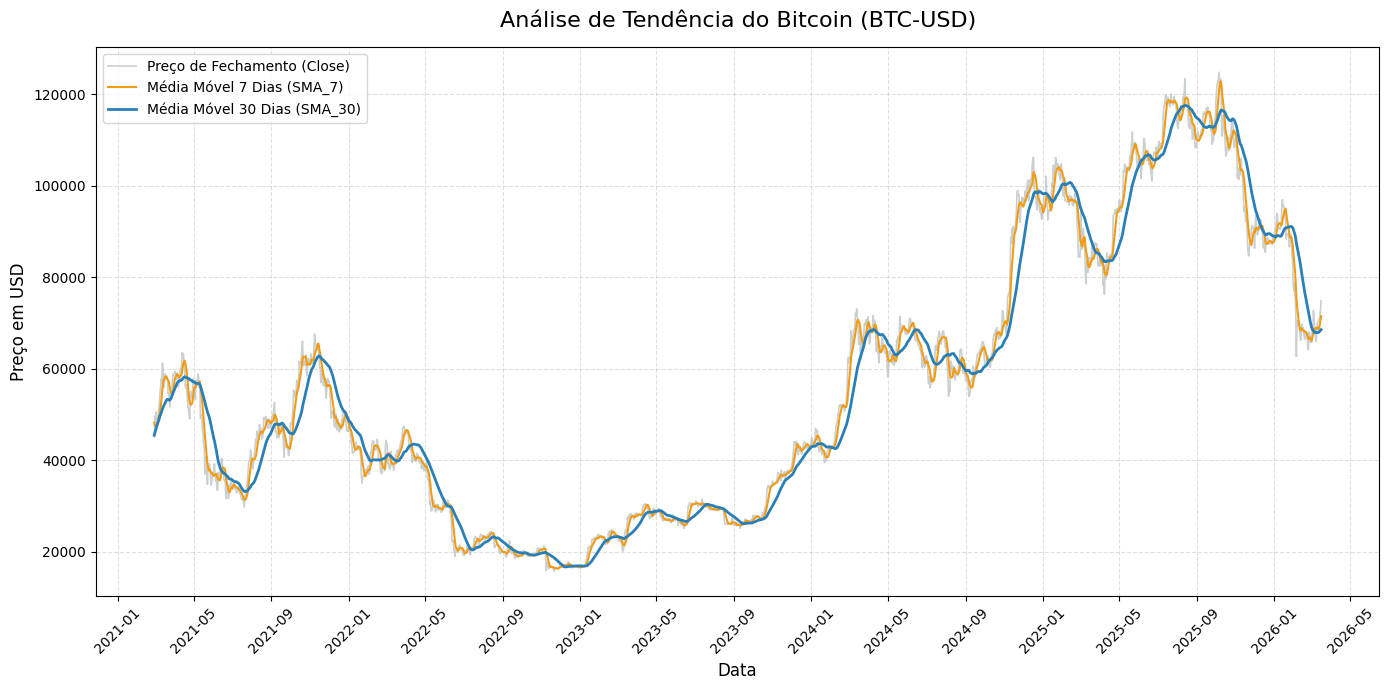

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# download dos dados novamente (para garantir base limpa)
ticker = "BTC-USD"
df_plot = yf.download(ticker, start="2021-01-30", end="2026-03-17")

# ajuste caso o yfinance traga colunas em MultiIndex
if isinstance(df_plot.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)

# recriar as médias móveis para o gráfico
df_plot['SMA_7'] = df_plot['Close'].rolling(window=7).mean()
df_plot['SMA_30'] = df_plot['Close'].rolling(window=30).mean()

# removendo os dias iniciais nulos
df_plot = df_plot.dropna()

plt.figure(figsize=(14, 7))

plt.plot(df_plot.index, df_plot['Close'], label='Preço de Fechamento (Close)', color='#bdc3c7', linewidth=1.2, alpha=0.8)
plt.plot(df_plot.index, df_plot['SMA_7'], label='Média Móvel 7 Dias (SMA_7)', color='#f39c12', linewidth=1.5)
plt.plot(df_plot.index, df_plot['SMA_30'], label='Média Móvel 30 Dias (SMA_30)', color='#2980b9', linewidth=2)

plt.title('Análise de Tendência do Bitcoin (BTC-USD)', fontsize=16, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço em USD', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()